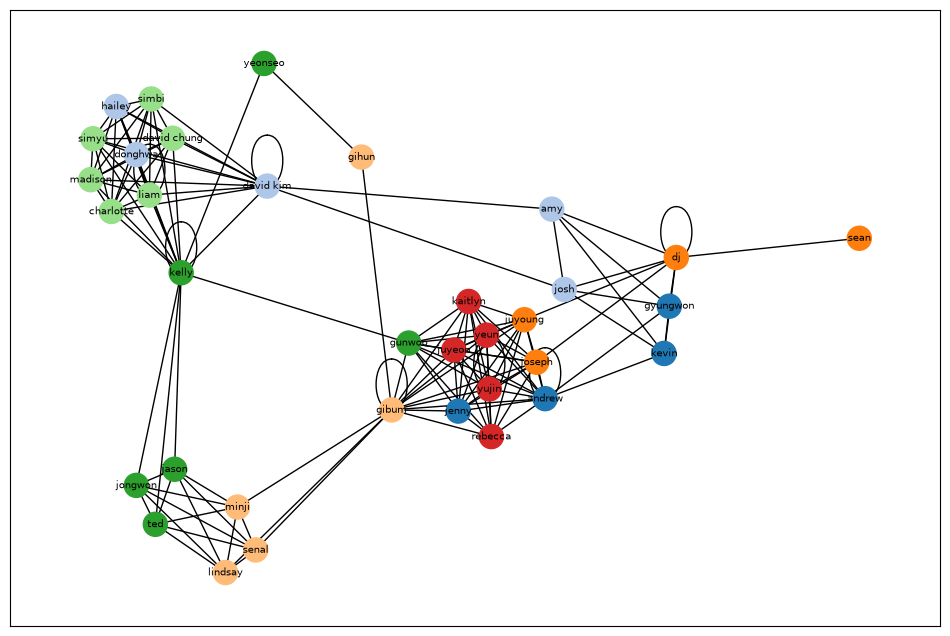

<Figure size 640x480 with 0 Axes>

In [40]:
import itertools

import matplotlib.pyplot as plt
import networkx as nx
import pandas as pd

df = pd.read_csv('hw1.csv')

G = nx.Graph()
G.add_nodes_from(df['individual'])
G.add_nodes_from(df['driver'])

allowed_edges = set(df[['individual', 'driver']].itertuples(index=False, name=None))

for _, individuals in df.groupby('address')['individual']:
    allowed_edges.update(itertools.combinations(individuals, 2))

G.add_edges_from(allowed_edges)

drivers = sorted(df['driver'].unique())
driver_colors = {
    driver: plt.cm.tab20(index % 20)
    for index, driver in enumerate(drivers)
}
individual_drivers = df.set_index('individual')['driver'].to_dict()
node_colors = [
    driver_colors.get(individual_drivers.get(node, node), 'lightgray')
    for node in G.nodes
]

plt.figure(figsize=(12, 8))
nx.draw_networkx(
    G,
    pos=nx.spring_layout(G, seed=42),
    with_labels=True,
    node_color=node_colors,
    edge_color='black',
    node_size=300,
    font_size=7,
)
plt.show()
plt.savefig('drivers network', dpi=300)

In [26]:
#q2.b
import polars as pl
df = pl.read_csv('cook_social_2020.csv')
new_col = df['datetime'].str.to_datetime('%Y-%m-%dT%H:%M:%S%Z', strict=False)
df.replace_column(0, new_col)
df = df.drop_nulls()
bad_values = {'UK', 'UKM', 'UKF'}
df = df.filter(~pl.col('focal_id').is_in(bad_values))
df = df.filter(~pl.col('partner_id').is_in(bad_values))
df = df.filter(pl.col('datetime').dt.year() == 2020)
condo_names = df['condo'].unique().to_list()

In [27]:
#q2.c
def condo_dict(type):
    dict = {}
    for condo in condo_names:
        condo_df = df.filter(pl.col('condo') == condo)
        interaction_df = condo_df.filter(pl.col('partner_interaction') == type)
        G = nx.Graph()
        
        nodes = (
            set(condo_df["focal_id"].to_list()) |
            set(condo_df["partner_id"].to_list())
        )
        G.add_nodes_from(nodes)

        edges = interaction_df.select(
            ["focal_id", "partner_id"]
        ).iter_rows()
        G.add_edges_from(edges)

        dict[condo] = G

    return dict

cm = condo_dict('5 CM Partners')
touch = condo_dict('Touch Partners')
mating = condo_dict('Mating Partners')

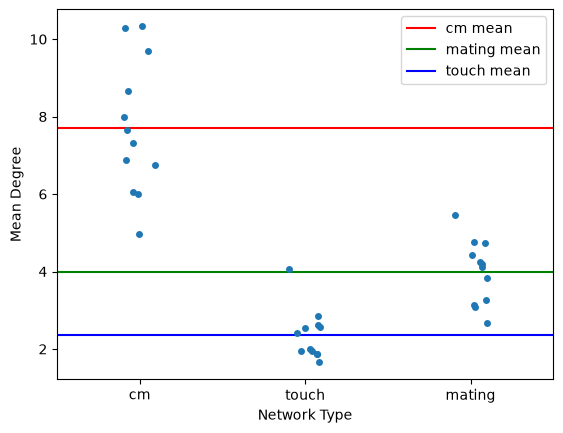

In [28]:
#q2.d
import seaborn as sns

def mean_degree(G):
    n = G.number_of_nodes()
    m = G.number_of_edges()

    k_list = []
    for j in G.nodes:
        k_list.append(G.degree[j])

    k_G = sum(k_list) / len(k_list)  

    return k_G

degree_data = []

for condo in condo_names:

    degree_data.append({
        "Condo": condo,
        "Network Type": "cm",
        "Mean Degree": mean_degree(cm[condo])
    })

    degree_data.append({
        "Condo": condo,
        "Network Type": "touch",
        "Mean Degree": mean_degree(touch[condo])
    })

    degree_data.append({
        "Condo": condo,
        "Network Type": "mating",
        "Mean Degree": mean_degree(mating[condo])
    })

degree_df = pd.DataFrame(degree_data)

overall_mean = degree_df.groupby('Network Type', as_index=False)['Mean Degree'].mean()

ax = sns.stripplot(data=degree_df, x='Network Type', y='Mean Degree')
ax.axhline(overall_mean.iat[0, 1], color='red', label='cm mean')
ax.axhline(overall_mean.iat[1, 1], color='green', label='mating mean')
ax.axhline(overall_mean.iat[2, 1], color='blue', label='touch mean')
ax.legend()


the 5cm mean is higher than the other two indicating that on average more beetles have 5cm interactions with other beetles than the other two types

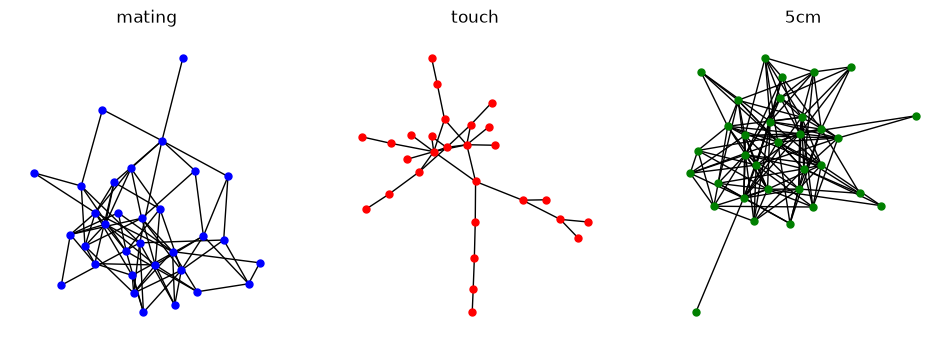

In [30]:
#q2.e
df_2B = df.filter((pl.col("condo") == "2B"))
df_2B_mating = df_2B.filter((pl.col('partner_interaction') == 'Mating Partners'))
df_2B_touch = df_2B.filter((pl.col('partner_interaction') == 'Touch Partners'))
df_2B_5cm = df_2B.filter((pl.col('partner_interaction') == '5 CM Partners'))

G_mating = nx.Graph()
G_mating.add_nodes_from(df_2B_mating["focal_id"].to_list())
G_mating.add_edges_from(df_2B_mating["focal_id", "partner_id"].iter_rows())

G_touch = nx.Graph()
G_touch.add_nodes_from(df_2B_touch["focal_id"].to_list())
G_touch.add_edges_from(df_2B_touch["focal_id", "partner_id"].iter_rows())

G_5cm = nx.Graph()
G_5cm.add_nodes_from(df_2B_5cm["focal_id"].to_list())
G_5cm.add_edges_from(df_2B_5cm["focal_id", "partner_id"].iter_rows())

plt.figure(figsize=(12,4))
plt.subplot(1, 3, 1)
nx.draw(G_mating, with_labels=False, node_size=25, node_color="blue")
plt.title('mating')

plt.subplot(1, 3, 2)
nx.draw(G_touch, with_labels=False, node_size=25, node_color="red")
plt.title('touch')

plt.subplot(1, 3, 3)
nx.draw(G_5cm, with_labels=False, node_size=25, node_color="green")
plt.title('5cm')

plt.savefig('2B networks', dpi=300)

The touch network seems less dense with nodes only being connected to one or two other nodes which seems unlike what would actually occur, where more beetles would touch each other without mating than otherwise. This might suggest that the touch interactions do not include mating interactions (mating does not count as touching). The 5cm network seems to be the most dense with most nodes being connected to several other nodes and those nodes being connected again to the original node's neighbors indicataing a higher clustering coefficient.

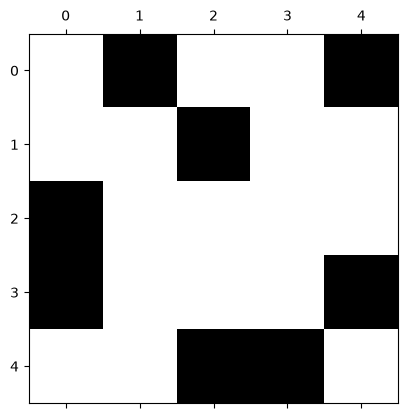

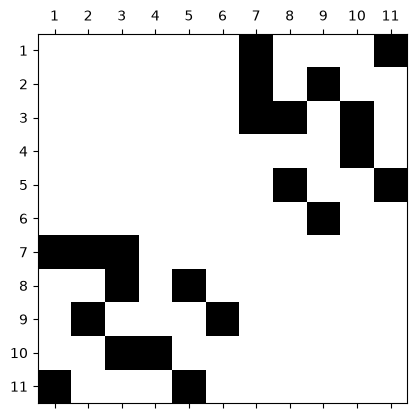

In [38]:
#q3.a
edges_1 = [
    (1, 2),
    (1, 5),
    (2, 3),
    (3, 1),
    (4, 1),
    (4, 5),
    (5, 3),
    (5, 4)
]

G1 = nx.DiGraph()
G1.add_nodes_from([1,2,3,4,5])
G1.add_edges_from(edges_1)

A1 = nx.to_numpy_array(
    G1,
    nodelist=[1, 2, 3, 4, 5]
)

plt.spy(A1)
plt.show()

edges_2 = [
    (7, 1),
    (7, 2),
    (7, 3),
    (8, 3),
    (8, 5),
    (9, 2),
    (9, 6),
    (10, 3),
    (10, 4),
    (11, 1),
    (11, 5)
]

G2 = nx.Graph()

G2.add_nodes_from([1,2,3,4,5,6,7,8,9,10,11])
G2.add_edges_from(edges_2)

A2 = nx.to_numpy_array(G2, nodelist= [1,2,3,4,5,6,7,8,9,10,11])

plt.spy(A2)

plt.xticks(range(11), [1,2,3,4,5,6,7,8,9,10,11])
plt.yticks(range(11), [1,2,3,4,5,6,7,8,9,10,11])

plt.show()